# NYC Asking Rent and Rental Inventory, 2016–2026

**Mapping Systems — Assignment 01: Loading and Visualizing Data**  
**Research question:** How did median asking rent and rental inventory change across New York City's five boroughs from July 2016 through June 2026?

## tl;dr

- Median asking rent rose in all five boroughs over the frozen ten-year window. The endpoint increase ranged from **44.5% in Brooklyn** to **76.2% in the Bronx**.
- Manhattan remained the highest-rent borough in June 2026 at **$4,965**, up **$1,565 (46.0%)** from July 2016.
- Rental inventory did not move in one direction: it ended **31.6% below** baseline in Manhattan and **24.0% below** in Staten Island, but **42.2% above** baseline in the Bronx.
- The monthly relationship between rent and inventory differs by borough. That variation is descriptive evidence, not proof that a change in listings caused a change in rent.

The assignment asks for map and non-map visualizations, inline reasoning about chosen attributes, and a clear account of what those attributes can and cannot tell us. The original brief is available on the [Mapping Systems course site](https://mapping-systems.org/lessons/assignments/loading-and-visualizing-data/).

## Context & Methods

### Why these two attributes?

`medianAskingRent` is a direct monthly signal of the advertised rental market. `rentalInventory` provides essential context because a rent value observed among a small or changing pool of listings may not represent the same market conditions as one observed among a broad pool. Looking at both attributes helps describe price movement and the changing StreetEasy listing sample without treating either measure as a complete account of housing affordability or supply.

### Sources

1. **Rental metrics:** a frozen extract from the [StreetEasy Data Dashboard](https://streeteasy.com/blog/data-dashboard/) master report, limited to five boroughs and 120 complete months from July 2016 through June 2026.
2. **Map geometry:** the project's local `nyc_neighborhoods.geojson` reference layer. Its 197 neighborhood polygons are dissolved by borough for this assignment. The boroughwide rental values are not neighborhood estimates.

### Key assumptions and interpretation limits

- **Asking rent is not paid rent.** It is the median advertised rent among StreetEasy listings available during a month. It does not measure what all existing tenants pay, concessions, lease renewals, or off-platform units.
- **Dollar values are nominal.** They are not adjusted for inflation, so the charts describe nominal market change rather than change in purchasing power.
- **Inventory is a platform sample.** It counts listings observed on StreetEasy, not the complete physical stock of available apartments. Platform coverage, listing practices, and small samples—especially Staten Island—can affect the series.
- **The analysis is descriptive.** Correlation, coincident movement, and before/after differences do not establish causality. Policy, construction, migration, seasonality, macroeconomic conditions, and listing composition are not controlled here.

## Data

### 1. Setup and locate project files

The path lookup searches upward from the current working directory, so the notebook can run from either the project root or this assignment folder without an absolute data path.

In [1]:
from pathlib import Path
from IPython.display import Markdown, display

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import patheffects
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


def locate_project_root(start: Path) -> Path:
    # Return the nearest parent containing the frozen rent dataset.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data/source/nyc_rent_monthly.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/source/nyc_rent_monthly.csv above the current directory."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
ASSIGNMENT_DIR = PROJECT_ROOT / "01_loading_and_visualizing_data"
OUTPUT_DIR = ASSIGNMENT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

RENT_PATH = PROJECT_ROOT / "data/source/nyc_rent_monthly.csv"
NEIGHBORHOOD_PATH = PROJECT_ROOT / "data/reference/nyc_neighborhoods.geojson"

START_MONTH = pd.Timestamp("2016-07-01")
END_MONTH = pd.Timestamp("2026-06-01")
BOROUGH_ORDER = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
BOROUGH_COLORS = {
    "Manhattan": "#1F4E79",
    "Brooklyn": "#E47A2E",
    "Queens": "#C49A24",
    "Bronx": "#708238",
    "Staten Island": "#B65C7A",
}
BOROUGH_LINESTYLES = {
    "Manhattan": "-",
    "Brooklyn": "--",
    "Queens": "-.",
    "Bronx": ":",
    "Staten Island": (0, (5, 2, 1, 2)),
}

mpl.rcParams.update(
    {
        "figure.facecolor": "#FAFAF7",
        "axes.facecolor": "#FAFAF7",
        "axes.edgecolor": "#495057",
        "axes.labelcolor": "#20252B",
        "axes.titlecolor": "#17202A",
        "axes.titlesize": 15,
        "axes.titleweight": "semibold",
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "grid.color": "#D9DEE3",
        "grid.linewidth": 0.8,
        "text.color": "#20252B",
        "xtick.color": "#495057",
        "ytick.color": "#495057",
    }
)

currency_axis = FuncFormatter(lambda value, _: f"${value:,.0f}")
percent_axis = FuncFormatter(lambda value, _: f"{value:.0f}%")


def finish_figure(fig, source_note: str):
    # Render the live Matplotlib figure inline; do not reload a saved image.
    fig.text(0.01, 0.012, source_note, fontsize=8.5, color="#5F6B73")
    plt.show()
    plt.close(fig)


print(f"Project root located: {PROJECT_ROOT.name}")
print(f"Rental data: {RENT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Geometry: {NEIGHBORHOOD_PATH.relative_to(PROJECT_ROOT)}")

Project root located: Mapping-System-Weekly-Assignments-Ci
Rental data: data/source/nyc_rent_monthly.csv
Geometry: data/reference/nyc_neighborhoods.geojson


### 2. Load and normalize the rental table

The source field names are converted to snake case with explicit units. Each row should represent one borough-month.

In [2]:
rent_data = pd.read_csv(RENT_PATH, parse_dates=["date"]).rename(
    columns={
        "medianAskingRent": "median_asking_rent_usd",
        "rentalInventory": "rental_inventory",
    }
)
rent_data = rent_data.sort_values(["borough", "date"]).reset_index(drop=True)

display(rent_data.head(10))

,date,borough,median_asking_rent_usd,rental_inventory
0,2016-07-01,Bronx,1700,708
1,2016-08-01,Bronx,1700,854
2,2016-09-01,Bronx,1700,883
3,2016-10-01,Bronx,1699,886
4,2016-11-01,Bronx,1675,899
5,2016-12-01,Bronx,1700,816
6,2017-01-01,Bronx,1700,919
7,2017-02-01,Bronx,1675,940
8,2017-03-01,Bronx,1750,951
9,2017-04-01,Bronx,1749,921


### 3. Validate grain, coverage, and completeness

These are blocking checks. The analysis stops if the row count, five-borough coverage, composite key, complete monthly sequence, required values, endpoint dates, or positive numeric domains do not match the frozen-data contract.

In [3]:
expected_dates = pd.date_range(START_MONTH, END_MONTH, freq="MS")
expected_boroughs = set(BOROUGH_ORDER)
required_columns = [
    "date",
    "borough",
    "median_asking_rent_usd",
    "rental_inventory",
]

dates_complete_by_borough = rent_data.groupby("borough")["date"].apply(
    lambda values: set(values) == set(expected_dates)
)
months_per_borough = rent_data.groupby("borough")["date"].nunique()

validation_checks = {
    "600 rows (5 boroughs × 120 months)": len(rent_data) == 600,
    "exactly five expected boroughs": set(rent_data["borough"]) == expected_boroughs,
    "120 distinct months in every borough": months_per_borough.eq(120).all(),
    "complete July 2016–June 2026 sequence in every borough": dates_complete_by_borough.all(),
    "unique borough-month key": not rent_data.duplicated(["borough", "date"]).any(),
    "no exact duplicate rows": not rent_data.duplicated().any(),
    "no nulls in required columns": not rent_data[required_columns].isna().any().any(),
    "expected first and last month": (
        rent_data["date"].min() == START_MONTH and rent_data["date"].max() == END_MONTH
    ),
    "positive rent and inventory values": (
        rent_data["median_asking_rent_usd"].gt(0).all()
        and rent_data["rental_inventory"].gt(0).all()
    ),
}

validation_results = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "status": ["PASS" if passed else "FAIL" for passed in validation_checks.values()],
    }
)
assert all(validation_checks.values()), validation_results.query("status == 'FAIL'")
display(validation_results)
display(
    months_per_borough.reindex(BOROUGH_ORDER)
    .rename("distinct_months")
    .to_frame()
)

,check,status
0,600 rows (5 boroughs × 120 months),PASS
1,exactly five expected boroughs,PASS
2,120 distinct months in every borough,PASS
3,complete July 2016–June 2026 sequence in every...,PASS
4,unique borough-month key,PASS
5,no exact duplicate rows,PASS
6,no nulls in required columns,PASS
7,expected first and last month,PASS
8,positive rent and inventory values,PASS


,distinct_months
borough,
Manhattan,120
Brooklyn,120
Queens,120
Bronx,120
Staten Island,120


### 4. Derive baseline comparisons and indices

- `rent_index` and `inventory_index` set July 2016 to 100 separately for each borough.
- Dollar and percentage changes compare the exact July 2016 and June 2026 endpoints.
- Year-over-year rates compare each month with the same month one year earlier and are used only for the distribution view.

In [4]:
grouped = rent_data.groupby("borough", sort=False)
rent_data["rent_index"] = grouped["median_asking_rent_usd"].transform(
    lambda values: values / values.iloc[0] * 100
)
rent_data["inventory_index"] = grouped["rental_inventory"].transform(
    lambda values: values / values.iloc[0] * 100
)
rent_data["rent_change_from_baseline_usd"] = grouped[
    "median_asking_rent_usd"
].transform(lambda values: values - values.iloc[0])
rent_data["rent_growth_from_baseline_pct"] = rent_data["rent_index"] - 100
rent_data["inventory_change_from_baseline"] = grouped[
    "rental_inventory"
].transform(lambda values: values - values.iloc[0])
rent_data["inventory_growth_from_baseline_pct"] = rent_data["inventory_index"] - 100
rent_data["rent_yoy_pct"] = grouped["median_asking_rent_usd"].pct_change(12) * 100
rent_data["inventory_yoy_pct"] = grouped["rental_inventory"].pct_change(12) * 100

baseline = rent_data.loc[
    rent_data["date"].eq(START_MONTH),
    ["borough", "median_asking_rent_usd", "rental_inventory"],
].rename(
    columns={
        "median_asking_rent_usd": "baseline_rent_usd",
        "rental_inventory": "baseline_inventory",
    }
)
endpoint = rent_data.loc[
    rent_data["date"].eq(END_MONTH),
    ["borough", "median_asking_rent_usd", "rental_inventory"],
].rename(
    columns={
        "median_asking_rent_usd": "end_rent_usd",
        "rental_inventory": "end_inventory",
    }
)

change_summary = baseline.merge(endpoint, on="borough", validate="one_to_one")
change_summary["rent_change_usd"] = (
    change_summary["end_rent_usd"] - change_summary["baseline_rent_usd"]
)
change_summary["rent_growth_pct"] = (
    change_summary["rent_change_usd"] / change_summary["baseline_rent_usd"] * 100
)
change_summary["inventory_change"] = (
    change_summary["end_inventory"] - change_summary["baseline_inventory"]
)
change_summary["inventory_growth_pct"] = (
    change_summary["inventory_change"] / change_summary["baseline_inventory"] * 100
)
change_summary["baseline_month"] = START_MONTH.strftime("%Y-%m")
change_summary["end_month"] = END_MONTH.strftime("%Y-%m")
change_summary["borough"] = pd.Categorical(
    change_summary["borough"], categories=BOROUGH_ORDER, ordered=True
)
change_summary = change_summary.sort_values("borough").reset_index(drop=True)

assert len(change_summary) == 5
assert np.allclose(
    rent_data.groupby("borough")["rent_index"].first().to_numpy(), 100
)
assert np.allclose(
    rent_data.groupby("borough")["inventory_index"].first().to_numpy(), 100
)

rent_data.to_csv(
    OUTPUT_DIR / "nyc_rent_monthly_derived.csv", index=False, date_format="%Y-%m"
)
change_summary.to_csv(OUTPUT_DIR / "borough_change_summary.csv", index=False)

summary_view = change_summary[
    [
        "borough",
        "baseline_rent_usd",
        "end_rent_usd",
        "rent_change_usd",
        "rent_growth_pct",
        "baseline_inventory",
        "end_inventory",
        "inventory_change",
        "inventory_growth_pct",
    ]
].copy()
display(
    summary_view.style.format(
        {
            "baseline_rent_usd": "${:,.0f}",
            "end_rent_usd": "${:,.0f}",
            "rent_change_usd": "+${:,.0f}",
            "rent_growth_pct": "+{:.1f}%",
            "baseline_inventory": "{:,.0f}",
            "end_inventory": "{:,.0f}",
            "inventory_change": "{:+,.0f}",
            "inventory_growth_pct": "{:+.1f}%",
        }
    )
)

,borough,baseline_rent_usd,end_rent_usd,rent_change_usd,rent_growth_pct,baseline_inventory,end_inventory,inventory_change,inventory_growth_pct
0,Manhattan,"$3,400","$4,965","+$1,565",+46.0%,"24,171","16,538","-7,633",-31.6%
1,Brooklyn,"$2,699","$3,900","+$1,201",+44.5%,"12,829","13,491",+662,+5.2%
2,Queens,"$2,305","$3,350","+$1,045",+45.3%,"4,049","4,668",+619,+15.3%
3,Bronx,"$1,700","$2,995","+$1,295",+76.2%,708,"1,007",+299,+42.2%
4,Staten Island,"$2,050","$3,300","+$1,250",+61.0%,75,57,-18,-24.0%


In [5]:
largest_growth = change_summary.loc[change_summary["rent_growth_pct"].idxmax()]
highest_endpoint = change_summary.loc[change_summary["end_rent_usd"].idxmax()]
inventory_low = change_summary.loc[change_summary["inventory_growth_pct"].idxmin()]
inventory_high = change_summary.loc[change_summary["inventory_growth_pct"].idxmax()]

display(
    Markdown(
        f'''
**Endpoint read:** {largest_growth['borough']} recorded the largest percentage rise in asking rent
({largest_growth['rent_growth_pct']:.1f}%), while {highest_endpoint['borough']} had the highest June 2026
median asking rent (${highest_endpoint['end_rent_usd']:,.0f}). Inventory change ranged from
{inventory_low['inventory_growth_pct']:.1f}% in {inventory_low['borough']} to
+{inventory_high['inventory_growth_pct']:.1f}% in {inventory_high['borough']}.

These values compare two selected endpoints; the full monthly series below is needed to see the path between them.
'''
    )
)


**Endpoint read:** Bronx recorded the largest percentage rise in asking rent
(76.2%), while Manhattan had the highest June 2026
median asking rent ($4,965). Inventory change ranged from
-31.6% in Manhattan to
+42.2% in Bronx.

These values compare two selected endpoints; the full monthly series below is needed to see the path between them.


## Results

### 5. Map: boroughwide asking-rent growth

The neighborhood geometry is dissolved into five borough shapes in EPSG:2263, then joined one-to-one with the endpoint summary. A 25-foot outward/inward cartographic closing removes narrow sliver gaps between source polygons while changing total dissolved area by less than 0.2%. The map uses a single blue color ramp because it encodes one ordered measure: nominal percentage growth in median asking rent.

In [6]:
neighborhoods = gpd.read_file(NEIGHBORHOOD_PATH)
geometry_checks = {
    "geometry is EPSG:4326": neighborhoods.crs.to_epsg() == 4326,
    "197 neighborhood features": len(neighborhoods) == 197,
    "all geometries present": neighborhoods.geometry.notna().all(),
    "all geometries valid": neighborhoods.geometry.is_valid.all(),
    "five borough labels": set(neighborhoods["borough"]) == set(BOROUGH_ORDER),
}
assert all(geometry_checks.values()), geometry_checks

borough_geometry_raw = neighborhoods[["borough", "geometry"]].to_crs(2263).dissolve(
    by="borough", as_index=False
)
raw_dissolved_area = borough_geometry_raw.geometry.area.sum()
borough_geometry = borough_geometry_raw.copy()
borough_geometry.geometry = borough_geometry.buffer(25, resolution=1).buffer(
    -25, resolution=1
)
area_change_pct = (
    borough_geometry.geometry.area.sum() / raw_dissolved_area - 1
) * 100
assert abs(area_change_pct) < 0.2
borough_geometry = borough_geometry.to_crs(4326)
geometry_checks["25-foot closing changes dissolved area by <0.2%"] = (
    abs(area_change_pct) < 0.2
)
borough_map = borough_geometry.merge(
    change_summary[
        [
            "borough",
            "baseline_rent_usd",
            "end_rent_usd",
            "rent_change_usd",
            "rent_growth_pct",
            "baseline_inventory",
            "end_inventory",
            "inventory_growth_pct",
        ]
    ],
    on="borough",
    how="left",
    validate="one_to_one",
)
assert len(borough_map) == 5
assert borough_map["rent_growth_pct"].notna().all()
assert borough_map.geometry.is_valid.all()

borough_map.to_file(OUTPUT_DIR / "borough_rent_growth.geojson", driver="GeoJSON")

map_checks = pd.DataFrame(
    {
        "check": [*geometry_checks.keys(), "five-row one-to-one rental join"],
        "status": [
            *["PASS" if value else "FAIL" for value in geometry_checks.values()],
            "PASS",
        ],
    }
)
display(map_checks)

,check,status
0,geometry is EPSG:4326,PASS
1,197 neighborhood features,PASS
2,all geometries present,PASS
3,all geometries valid,PASS
4,five borough labels,PASS
5,25-foot closing changes dissolved area by <0.2%,PASS
6,five-row one-to-one rental join,PASS


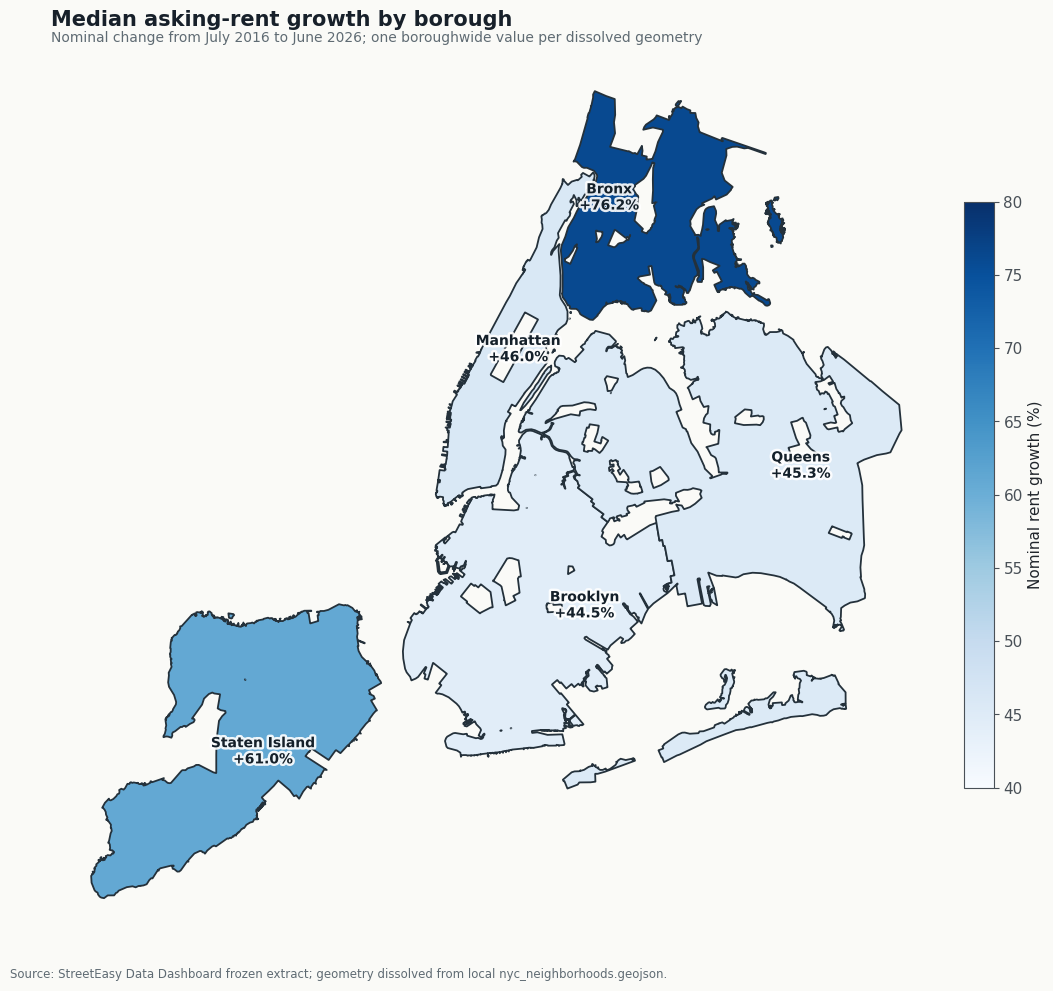

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 10))
borough_map.plot(
    ax=ax,
    column="rent_growth_pct",
    cmap="Blues",
    vmin=40,
    vmax=80,
    linewidth=1.3,
    edgecolor="#24313B",
    legend=True,
    legend_kwds={"label": "Nominal rent growth (%)", "shrink": 0.66, "pad": 0.02},
)

label_points = borough_map.to_crs(2263).representative_point().to_crs(4326)
label_offsets = {
    "Manhattan": (-0.015, -0.005),
    "Brooklyn": (0.004, -0.006),
    "Queens": (0.008, 0.003),
    "Bronx": (0.000, 0.004),
    "Staten Island": (0.000, 0.000),
}
for (_, row), point in zip(borough_map.iterrows(), label_points):
    dx, dy = label_offsets[row["borough"]]
    label = f"{row['borough']}\n+{row['rent_growth_pct']:.1f}%"
    annotation = ax.text(
        point.x + dx,
        point.y + dy,
        label,
        ha="center",
        va="center",
        fontsize=10,
        weight="semibold",
        color="#14202A",
    )
    annotation.set_path_effects(
        [patheffects.withStroke(linewidth=3.5, foreground="#FFFFFF", alpha=0.9)]
    )

ax.set_title("Median asking-rent growth by borough", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Nominal change from July 2016 to June 2026; one boroughwide value per dissolved geometry",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6B73",
)
ax.set_axis_off()
fig.tight_layout(rect=(0, 0.035, 1, 0.98))
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract; geometry dissolved from local nyc_neighborhoods.geojson.",
)

The Bronx has the largest endpoint percentage increase, while Brooklyn has the smallest of the five. The map intentionally does **not** imply uniform conditions within each borough: every neighborhood polygon inherits the same boroughwide statistic after the dissolve. A finer-grained rental dataset would be required to analyze within-borough variation.

#### Interactive version with Lonboard

The same five-row GeoDataFrame is constructed below as a Lonboard map for local interaction. The directly plotted static map immediately above remains the durable GitHub fallback.

In [8]:
from lonboard import Map, PolygonLayer
from lonboard.basemap import CartoStyle, MaplibreBasemap

color_norm = Normalize(
    vmin=borough_map["rent_growth_pct"].min(),
    vmax=borough_map["rent_growth_pct"].max(),
)
fill_colors = (
    plt.get_cmap("Blues")(color_norm(borough_map["rent_growth_pct"])) * 255
).astype(np.uint8)
fill_colors[:, 3] = 205

polygon_layer = PolygonLayer.from_geopandas(
    borough_map[
        [
            "borough",
            "baseline_rent_usd",
            "end_rent_usd",
            "rent_growth_pct",
            "inventory_growth_pct",
            "geometry",
        ]
    ],
    get_fill_color=fill_colors,
    get_line_color=[28, 39, 49, 230],
    line_width_min_pixels=1.4,
    pickable=True,
)
interactive_map = Map(
    polygon_layer,
    basemap=MaplibreBasemap(style=CartoStyle.Positron),
    height=520,
)
display(interactive_map)
print("Lonboard map displayed from the same five-row GeoDataFrame used above.")

Lonboard map displayed from the same five-row GeoDataFrame used above.


### 6. Line chart: the full asking-rent path

A multi-series line chart is appropriate because the question concerns continuous monthly movement over 120 observations per borough. Color and line style both distinguish boroughs.

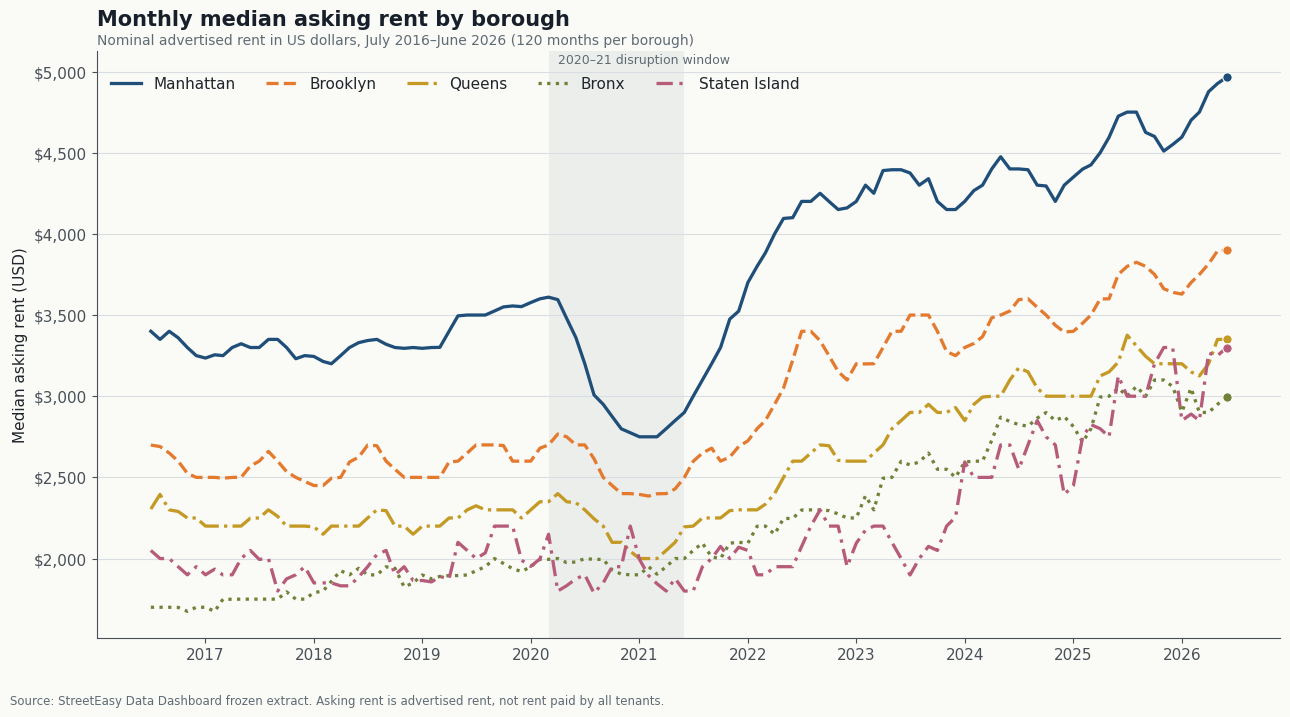

In [9]:
fig, ax = plt.subplots(figsize=(13, 7.5))
for borough in BOROUGH_ORDER:
    borough_series = rent_data.loc[rent_data["borough"].eq(borough)]
    ax.plot(
        borough_series["date"],
        borough_series["median_asking_rent_usd"],
        color=BOROUGH_COLORS[borough],
        linestyle=BOROUGH_LINESTYLES[borough],
        linewidth=2.35,
        label=borough,
    )
    last_row = borough_series.iloc[-1]
    ax.scatter(
        last_row["date"],
        last_row["median_asking_rent_usd"],
        color=BOROUGH_COLORS[borough],
        edgecolor="#FFFFFF",
        linewidth=0.8,
        s=46,
        zorder=4,
    )

ax.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-06-01"),
    color="#697782",
    alpha=0.09,
    linewidth=0,
)
ax.text(
    pd.Timestamp("2020-04-01"),
    5050,
    "2020–21 disruption window",
    fontsize=9,
    color="#5F6B73",
)
ax.set_title("Monthly median asking rent by borough", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "Nominal advertised rent in US dollars, July 2016–June 2026 (120 months per borough)",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6B73",
)
ax.set_ylabel("Median asking rent (USD)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(currency_axis)
ax.grid(axis="y")
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=5, loc="upper left", frameon=False, bbox_to_anchor=(0, 0.98))
fig.tight_layout(rect=(0, 0.045, 1, 0.96))
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract. Asking rent is advertised rent, not rent paid by all tenants.",
)

Manhattan, Brooklyn, and Queens show visible rent declines around 2020–early 2021 before rising to much higher endpoints. The highlighted interval is a time reference, not a causal claim. The chart does not isolate the effects of the pandemic, policy, migration, seasonality, or changes in listing composition.

### 7. Indexed trends: compare change on a common baseline

Absolute dollars and listing counts are not directly comparable across boroughs. Setting each borough to 100 in July 2016 preserves proportional change while keeping rent and inventory in separate panels.

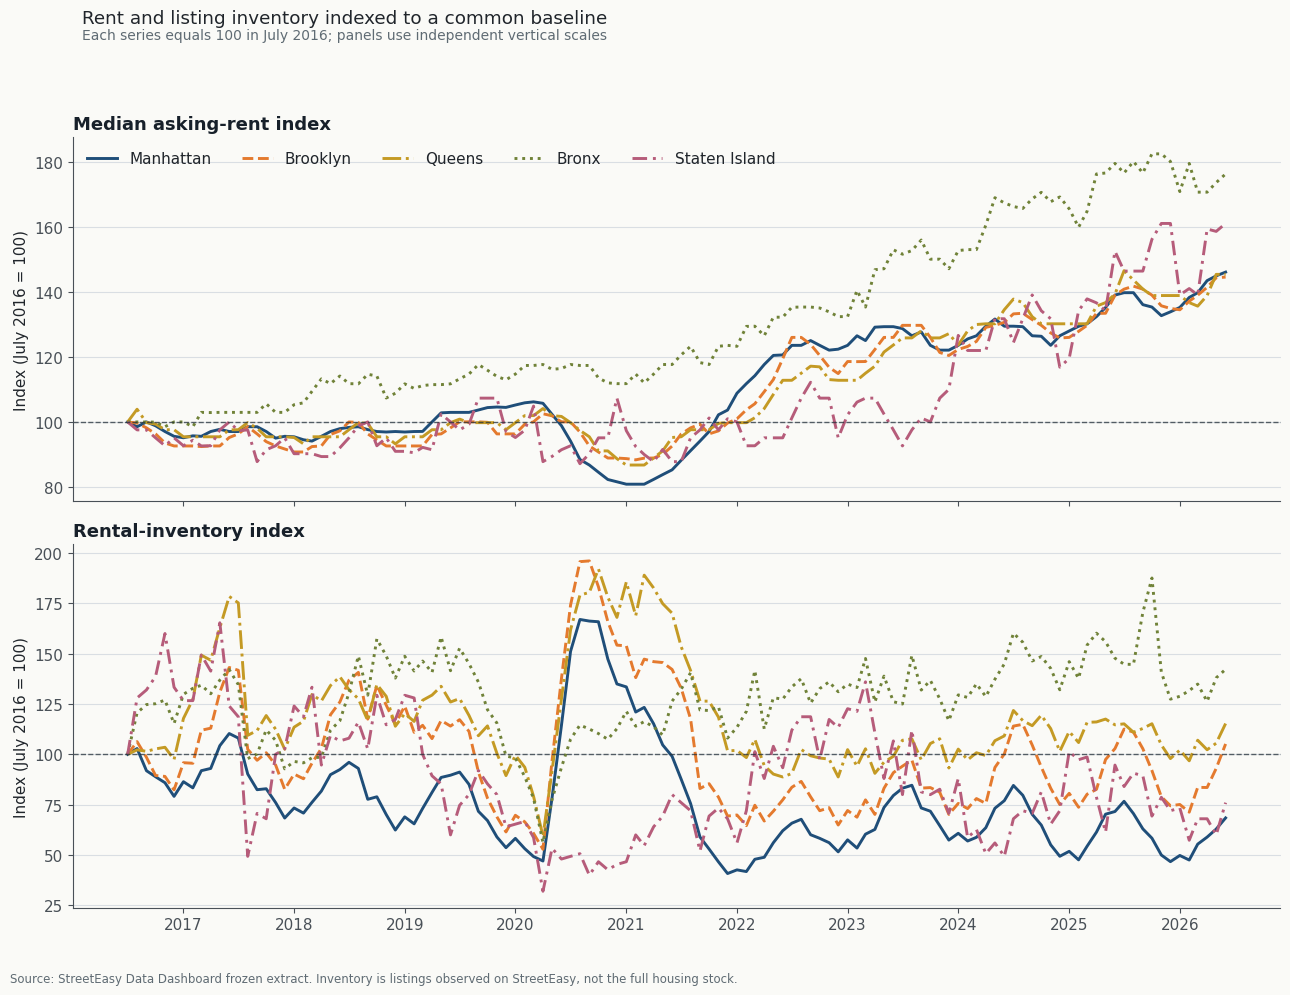

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
panel_specs = [
    ("rent_index", "Median asking-rent index", "Index (July 2016 = 100)"),
    ("inventory_index", "Rental-inventory index", "Index (July 2016 = 100)"),
]

for ax, (column, title, ylabel) in zip(axes, panel_specs):
    for borough in BOROUGH_ORDER:
        borough_series = rent_data.loc[rent_data["borough"].eq(borough)]
        ax.plot(
            borough_series["date"],
            borough_series[column],
            color=BOROUGH_COLORS[borough],
            linestyle=BOROUGH_LINESTYLES[borough],
            linewidth=2.1,
            label=borough,
        )
    ax.axhline(100, color="#25313A", linewidth=1, linestyle="--", alpha=0.75)
    ax.set_title(title, loc="left", fontsize=13)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(ncol=5, loc="upper left", frameon=False)
axes[-1].set_xlabel("")
fig.suptitle("Rent and listing inventory indexed to a common baseline", x=0.065, ha="left", y=0.985)
fig.text(
    0.065,
    0.955,
    "Each series equals 100 in July 2016; panels use independent vertical scales",
    fontsize=10,
    color="#5F6B73",
)
fig.tight_layout(rect=(0, 0.045, 1, 0.93))
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract. Inventory is listings observed on StreetEasy, not the full housing stock.",
)

The index view reveals different scales and timing. Inventory rose sharply in several boroughs during 2020, while asking-rent indices weakened in Manhattan, Brooklyn, and Queens. By June 2026, every rent index is above 144, but endpoint inventory indices range from 68.4 in Manhattan to 142.2 in the Bronx. The common baseline supports proportional comparison; it does not make the underlying listing samples equally representative.

### 8. Endpoint comparison: rent and inventory changed differently

Two zero-referenced bar panels compare the percentage difference between the same start and end months. The signed inventory panel makes increases and decreases explicit.

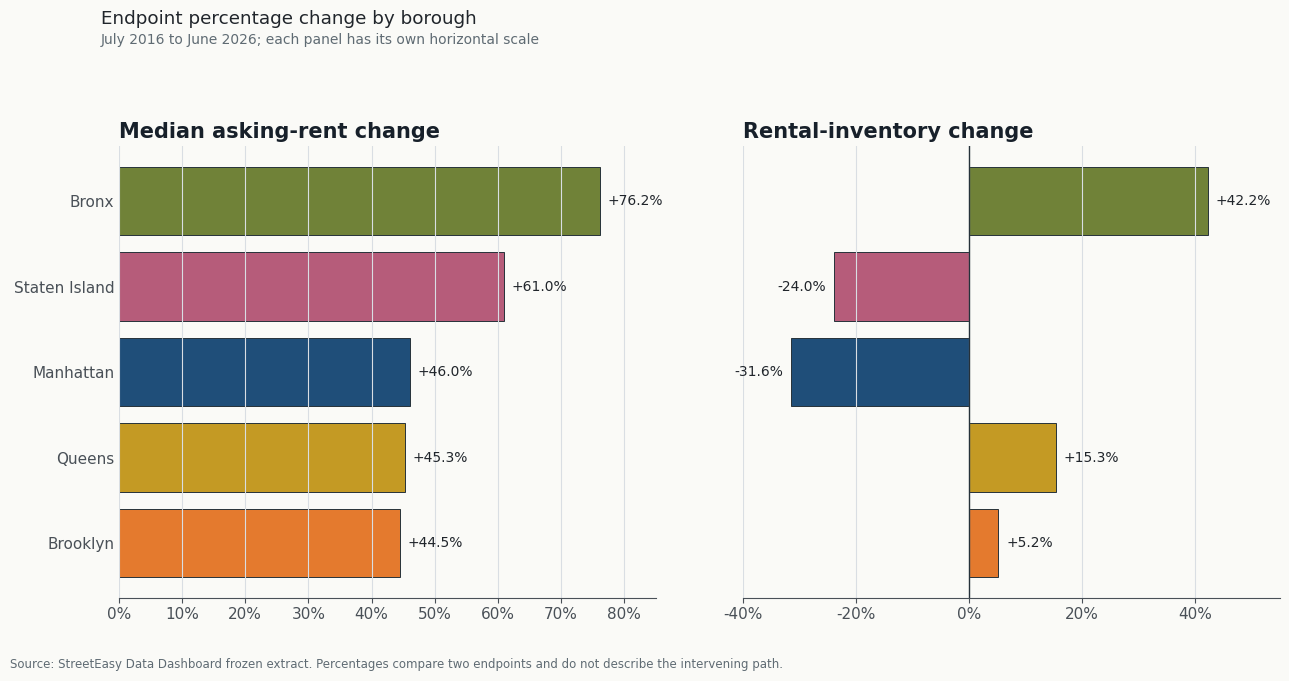

In [11]:
comparison = change_summary.sort_values("rent_growth_pct", ascending=True).copy()
y_positions = np.arange(len(comparison))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.8), sharey=True)
rent_colors = [BOROUGH_COLORS[str(value)] for value in comparison["borough"]]

axes[0].barh(
    y_positions,
    comparison["rent_growth_pct"],
    color=rent_colors,
    edgecolor="#26323A",
    linewidth=0.7,
)
axes[1].barh(
    y_positions,
    comparison["inventory_growth_pct"],
    color=rent_colors,
    edgecolor="#26323A",
    linewidth=0.7,
)

axes[0].set_yticks(y_positions, comparison["borough"].astype(str))
axes[0].set_xlim(0, 85)
axes[1].set_xlim(-40, 55)
axes[1].axvline(0, color="#25313A", linewidth=1)

for y, value in zip(y_positions, comparison["rent_growth_pct"]):
    axes[0].text(value + 1.2, y, f"+{value:.1f}%", va="center", fontsize=10)
for y, value in zip(y_positions, comparison["inventory_growth_pct"]):
    offset = 1.4 if value >= 0 else -1.4
    axes[1].text(
        value + offset,
        y,
        f"{value:+.1f}%",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=10,
    )

axes[0].set_title("Median asking-rent change", loc="left")
axes[1].set_title("Rental-inventory change", loc="left")
for ax in axes:
    ax.xaxis.set_major_formatter(percent_axis)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

fig.suptitle("Endpoint percentage change by borough", x=0.08, ha="left", y=0.98)
fig.text(
    0.08,
    0.93,
    "July 2016 to June 2026; each panel has its own horizontal scale",
    fontsize=10,
    color="#5F6B73",
)
fig.tight_layout(rect=(0, 0.055, 1, 0.89), w_pad=3.5)
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract. Percentages compare two endpoints and do not describe the intervening path.",
)

### 9. Distribution: year-over-year asking-rent changes

Endpoint growth can conceal volatility. A box plot summarizes 108 rolling year-over-year observations per borough (the first 12 months have no prior-year comparison). The boxes show the middle 50% of observations; whiskers use the conventional 1.5×IQR rule, and points beyond them remain visible.

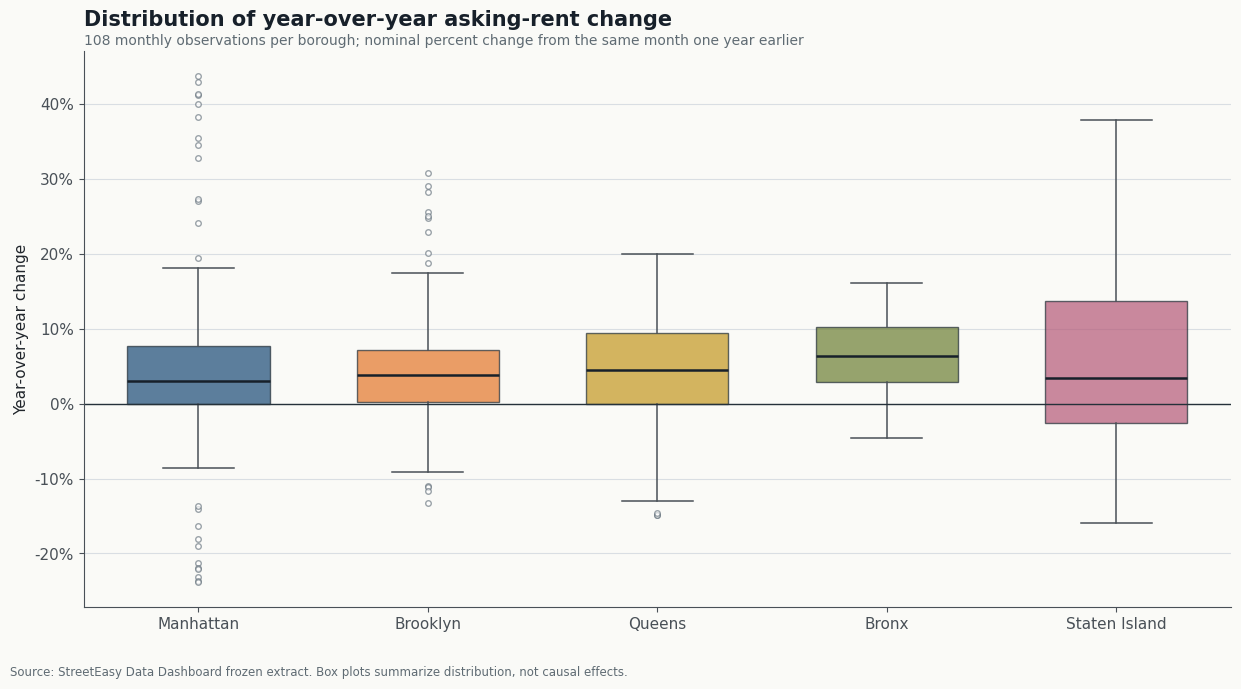

In [12]:
yoy_values = [
    rent_data.loc[rent_data["borough"].eq(borough), "rent_yoy_pct"].dropna().to_numpy()
    for borough in BOROUGH_ORDER
]
assert all(len(values) == 108 for values in yoy_values)

fig, ax = plt.subplots(figsize=(12.5, 7.2))
boxplot = ax.boxplot(
    yoy_values,
    tick_labels=BOROUGH_ORDER,
    patch_artist=True,
    widths=0.62,
    medianprops={"color": "#17202A", "linewidth": 1.8},
    whiskerprops={"color": "#495057", "linewidth": 1.1},
    capprops={"color": "#495057", "linewidth": 1.1},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#FFFFFF",
        "markeredgecolor": "#66737D",
        "markersize": 4,
        "alpha": 0.65,
    },
)
for patch, borough in zip(boxplot["boxes"], BOROUGH_ORDER):
    patch.set_facecolor(BOROUGH_COLORS[borough])
    patch.set_alpha(0.72)
    patch.set_edgecolor("#26323A")

ax.axhline(0, color="#25313A", linewidth=1)
ax.set_title("Distribution of year-over-year asking-rent change", loc="left", pad=18)
ax.text(
    0,
    1.01,
    "108 monthly observations per borough; nominal percent change from the same month one year earlier",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6B73",
)
ax.set_ylabel("Year-over-year change")
ax.yaxis.set_major_formatter(percent_axis)
ax.grid(axis="y")
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract. Box plots summarize distribution, not causal effects.",
)

The distributions overlap, but their centers and outliers differ. This view warns against reducing a ten-year series to a single endpoint rate. Because successive year-over-year observations overlap in time, they are not independent samples and are not used here for formal inference.

### 10. Relationship: asking-rent index versus inventory index

Each point is one borough-month. Faceting keeps every panel at the same grain and prevents borough differences in scale from being mistaken for a single pooled relationship. A simple fitted line and Pearson correlation summarize association only.

In [13]:
relationship_rows = []
for borough in BOROUGH_ORDER:
    borough_series = rent_data.loc[rent_data["borough"].eq(borough)]
    relationship_rows.append(
        {
            "borough": borough,
            "months": len(borough_series),
            "pearson_r": borough_series["rent_index"].corr(
                borough_series["inventory_index"]
            ),
        }
    )
relationship_summary = pd.DataFrame(relationship_rows)
assert relationship_summary["months"].eq(120).all()
display(relationship_summary.style.format({"pearson_r": "{:+.3f}"}))

,borough,months,pearson_r
0,Manhattan,120,-0.607
1,Brooklyn,120,-0.422
2,Queens,120,-0.461
3,Bronx,120,+0.498
4,Staten Island,120,-0.231


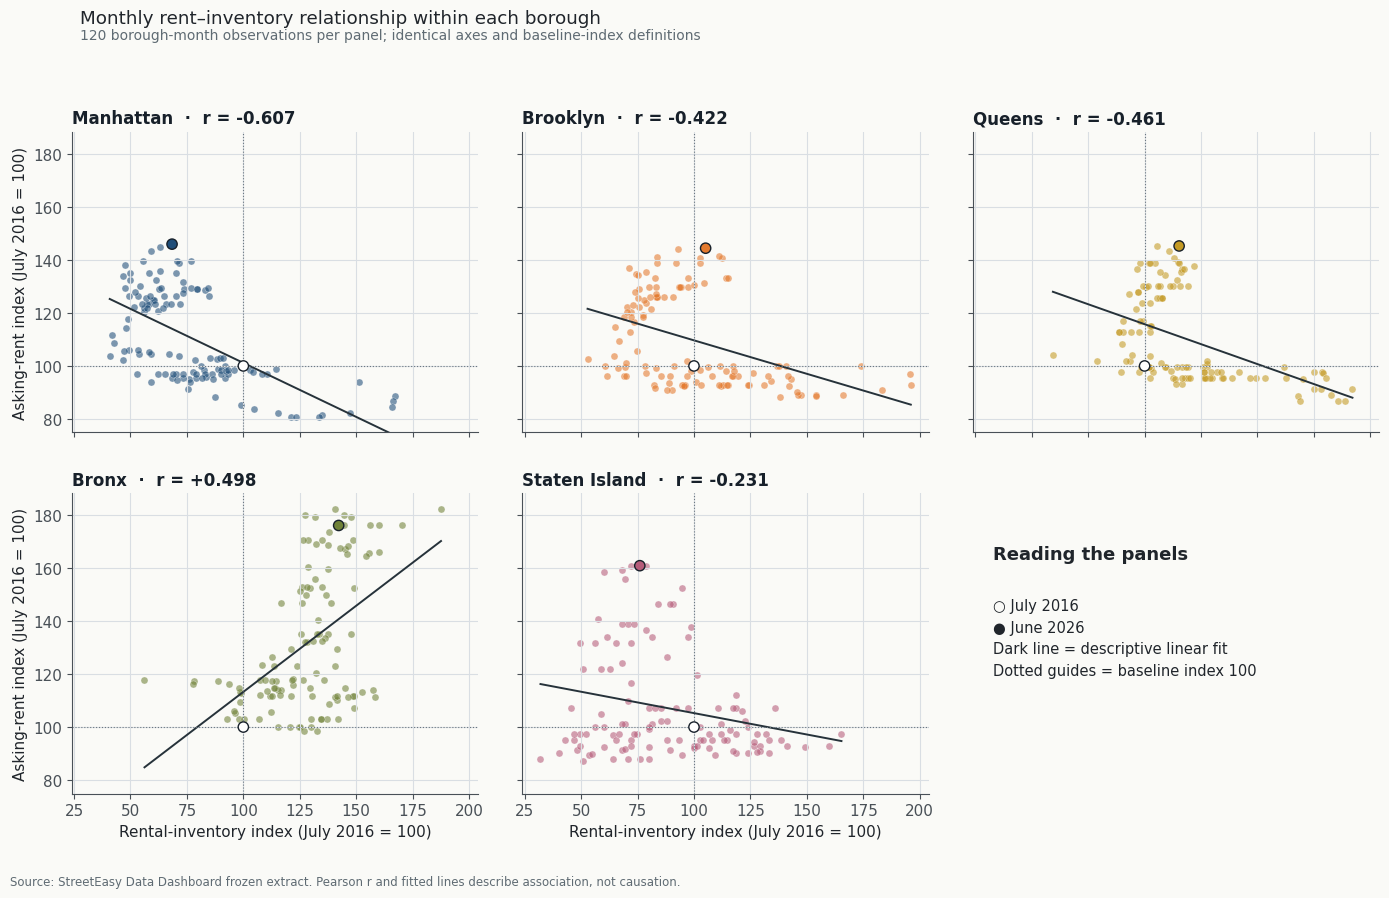

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
flat_axes = axes.ravel()

x_min, x_max = rent_data["inventory_index"].min(), rent_data["inventory_index"].max()
y_min, y_max = rent_data["rent_index"].min(), rent_data["rent_index"].max()

for ax, borough in zip(flat_axes, BOROUGH_ORDER):
    borough_series = rent_data.loc[rent_data["borough"].eq(borough)]
    x_values = borough_series["inventory_index"].to_numpy()
    y_values = borough_series["rent_index"].to_numpy()
    correlation = np.corrcoef(x_values, y_values)[0, 1]
    slope, intercept = np.polyfit(x_values, y_values, 1)
    fitted_x = np.linspace(x_values.min(), x_values.max(), 100)

    ax.scatter(
        x_values,
        y_values,
        s=26,
        color=BOROUGH_COLORS[borough],
        alpha=0.58,
        edgecolor="#FFFFFF",
        linewidth=0.35,
    )
    ax.plot(fitted_x, slope * fitted_x + intercept, color="#26323A", linewidth=1.4)
    ax.scatter(
        [x_values[0], x_values[-1]],
        [y_values[0], y_values[-1]],
        s=55,
        color=["#FFFFFF", BOROUGH_COLORS[borough]],
        edgecolor="#17202A",
        linewidth=1.0,
        zorder=4,
    )
    ax.set_title(f"{borough}  ·  r = {correlation:+.3f}", loc="left", fontsize=12)
    ax.axhline(100, color="#6C7881", linewidth=0.8, linestyle=":")
    ax.axvline(100, color="#6C7881", linewidth=0.8, linestyle=":")
    ax.grid(True)
    ax.spines[["top", "right"]].set_visible(False)

flat_axes[-1].axis("off")
flat_axes[-1].text(
    0.05,
    0.78,
    "Reading the panels",
    transform=flat_axes[-1].transAxes,
    fontsize=13,
    weight="semibold",
)
flat_axes[-1].text(
    0.05,
    0.65,
    "○ July 2016\n● June 2026\nDark line = descriptive linear fit\nDotted guides = baseline index 100",
    transform=flat_axes[-1].transAxes,
    fontsize=10.5,
    linespacing=1.55,
    va="top",
)

for ax in axes[-1, :2]:
    ax.set_xlabel("Rental-inventory index (July 2016 = 100)")
for ax in axes[:, 0]:
    ax.set_ylabel("Asking-rent index (July 2016 = 100)")

for ax in flat_axes[:5]:
    ax.set_xlim(x_min - 8, x_max + 8)
    ax.set_ylim(y_min - 6, y_max + 6)

fig.suptitle("Monthly rent–inventory relationship within each borough", x=0.06, ha="left", y=0.985)
fig.text(
    0.06,
    0.952,
    "120 borough-month observations per panel; identical axes and baseline-index definitions",
    fontsize=10,
    color="#5F6B73",
)
fig.tight_layout(rect=(0, 0.045, 1, 0.93), h_pad=2.2, w_pad=2.1)
finish_figure(
    fig,
    "Source: StreetEasy Data Dashboard frozen extract. Pearson r and fitted lines describe association, not causation.",
)

In [15]:
most_negative = relationship_summary.loc[relationship_summary["pearson_r"].idxmin()]
most_positive = relationship_summary.loc[relationship_summary["pearson_r"].idxmax()]
display(
    Markdown(
        f'''
The within-borough monthly correlations range from **{most_negative['pearson_r']:+.3f} in
{most_negative['borough']}** to **{most_positive['pearson_r']:+.3f} in {most_positive['borough']}**.
The changing sign is evidence against one simple citywide story. These raw time-series correlations are
affected by trend, seasonality, autocorrelation, listing composition, and omitted variables; they do not
estimate how inventory causes rent to change.
'''
    )
)


The within-borough monthly correlations range from **-0.607 in
Manhattan** to **+0.498 in Bronx**.
The changing sign is evidence against one simple citywide story. These raw time-series correlations are
affected by trend, seasonality, autocorrelation, listing composition, and omitted variables; they do not
estimate how inventory causes rent to change.


## Takeaways

1. **The endpoint pattern is citywide but uneven.** All five boroughs show higher nominal median asking rent in June 2026 than in July 2016, with increases from 44.5% to 76.2%.
2. **Price level and percentage growth answer different questions.** Manhattan has the highest endpoint rent, while the Bronx has the largest percentage increase from its lower baseline.
3. **Inventory is not a single supply story.** Endpoint listing counts fall in Manhattan and Staten Island but rise in Brooklyn, Queens, and the Bronx; the monthly paths include large temporary movements.
4. **The visual evidence is descriptive.** It can show timing, magnitude, distribution, and association in StreetEasy's advertised market. It cannot tell us what all tenants paid, isolate inflation, represent every rental unit, explain neighborhood variation, or identify a causal mechanism.

A next analytical step could add inflation-adjusted rent, neighborhood-level listings, housing completions, vacancy, or policy timing—but those would require a new, explicitly reconciled data model rather than being inferred from these two fields.

## Output inventory

The code above renders every map and chart directly in the Notebook. It also writes a five-row borough summary, the complete derived monthly table, and a GeoJSON map layer. The following cell verifies that those reusable data outputs exist and are non-empty.

In [16]:
expected_outputs = [
    "borough_change_summary.csv",
    "nyc_rent_monthly_derived.csv",
    "borough_rent_growth.geojson",
]
output_inventory = pd.DataFrame(
    {
        "file": expected_outputs,
        "exists": [(OUTPUT_DIR / name).exists() for name in expected_outputs],
        "bytes": [
            (OUTPUT_DIR / name).stat().st_size if (OUTPUT_DIR / name).exists() else 0
            for name in expected_outputs
        ],
    }
)
assert output_inventory["exists"].all()
assert output_inventory["bytes"].gt(0).all()
display(output_inventory)

,file,exists,bytes
0,borough_change_summary.csv,True,609
1,nyc_rent_monthly_derived.csv,True,84234
2,borough_rent_growth.geojson,True,463934
